# Classification Metrics - Confusion Matrix, ROC/PR, and Business Costs

<hr>

<center>
<div>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/mgmt_474_ai_logo_02-modified.png" width="200"/>
</div>
</center>

# <center><a class="tocSkip"></center>
# <center>QM47400 Predictive Analytics</center>
# <center>Professor: Davi Moreira </center>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/blob/main/notebooks/nb07_classification_metrics_thresholding_student.ipynb)

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Compute and interpret precision, recall, F1, ROC-AUC, and PR-AUC — and pair each metric with the business question it answers
2. Select thresholds based on business cost tradeoffs
3. Handle class imbalance at the evaluation level (metrics first)

---

> **📋 Participation Reminder:** This notebook contains **2 PAUSE-AND-DO exercises**. You are expected to complete all exercises before submitting your notebook.

---

## 💼 Why This Matters: When 95% Accuracy Isn't Good Enough

Your logistic regression for the **State Health Department** achieves 95% accuracy on the breast cancer data. The chief medical officer calls an urgent meeting: *"How many malignant cases did we miss?"* You check — and discover that 3 malignant tumors were classified as benign.

In medicine, a missed cancer (false negative) is catastrophic: delayed treatment, metastasis, potentially death. An unnecessary biopsy (false positive) causes stress and cost, but the patient survives. Accuracy alone cannot capture this asymmetry. You need metrics that distinguish between types of errors and a threshold that reflects the real-world cost of each mistake.

> **Today's focus:** Moving beyond accuracy to precision, recall, F1, and ROC analysis, and learning to set classification thresholds based on the cost of errors.

---

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.precision', 4)
RANDOM_SEED = 474
np.random.seed(RANDOM_SEED)
print("✓ Setup complete!")

✓ Setup complete!


**Reading the output:**

The setup cell imports every metric the Health Department will need to evaluate MedScreen: `confusion_matrix` for the raw error breakdown, `precision_score` and `recall_score` for the question "how many cancers did we catch?", `roc_auc_score` and `roc_curve` for threshold-independent model quality, and `precision_recall_curve` with `average_precision_score` for evaluation under class imbalance. The display helpers — `ConfusionMatrixDisplay`, `RocCurveDisplay`, `PrecisionRecallDisplay` — produce publication-quality plots with a single call, ready for a board presentation. The confirmation **"Setup complete!"** means all libraries loaded without conflict.

**Why this matters:** Having every metric function imported up front keeps the rest of the notebook focused on *interpreting* clinical performance rather than wrestling with imports.

---

## 1. Load Data and Train Model

Before we can study classification metrics, we need predictions to evaluate. The cell below loads the **breast cancer Wisconsin dataset** (569 samples, 30 features describing cell nuclei — `worst_radius`, `mean_texture`, `mean_concavity`, and others), applies the standard 60/20/20 stratified split, and fits the same Logistic Regression pipeline from the previous notebook.

We then extract both hard predictions (`y_pred_val`) and continuous probabilities (`y_proba_val`) from the validation set. Hard labels let us build a confusion matrix and compute precision/recall; probabilities let us sweep thresholds and plot ROC/PR curves — the full diagnostic toolkit the Health Department needs to assess whether MedScreen is ready for deployment.

> 💡 **Gemini Prompt:** "Load the breast cancer dataset, split it 60/20/20 with stratification, then build and fit a logistic regression pipeline (StandardScaler + LogisticRegression with max_iter=1000). Get hard predictions and class-1 probabilities on the validation set. Print set sizes and validation accuracy."
>
> **After running, verify:**
> - Train/Val/Test sizes are printed
> - Validation accuracy is reported (should be above 95%)
> - Both y_pred_val (hard labels) and y_proba_val (probabilities) are available> - All numerical outputs use standard decimal format — no scientific notation


In [2]:
# Load dataset
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

# Split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_SEED, stratify=y_temp)

# Train model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000))
])

pipeline.fit(X_train, y_train)
y_pred_val = pipeline.predict(X_val)
y_proba_val = pipeline.predict_proba(X_val)[:, 1]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Validation Accuracy: {pipeline.score(X_val, y_val):.4f}")

Train: 341 | Val: 114 | Test: 114
Validation Accuracy: 0.9561


**Reading the output:**

The dataset splits into **Train: 341 | Val: 114 | Test: 114**, following the 60/20/20 convention with stratification preserving the \~37% malignant / \~63% benign ratio in every partition. The Logistic Regression pipeline achieves **validation accuracy around 0.97** — impressive on the surface, but the chief medical officer's question is not "What percentage did you get right?" It is "How many malignant tumors did you miss?"

The variables `y_pred_val` (hard 0/1 labels at the default 0.5 threshold) and `y_proba_val` (continuous probabilities for the benign class) are now available. The remainder of this notebook uses these two arrays to compute every metric that answers the board's real questions.

**Key takeaway:** A single accuracy number is only the starting point. The next sections decompose this performance into the four cells of the confusion matrix and the metrics that derive from them.

---

## 2. The Confusion Matrix Deep Dive

Every classification metric the board will see — precision, recall, F1, specificity — is just arithmetic on four numbers. The confusion matrix tabulates those four outcomes for every patient MedScreen evaluated:

```
                    Predicted Negative    Predicted Positive
Actual Negative          TN                     FP
Actual Positive          FN                     TP
```

**In the screening context:**
- **True Positive (TP)**: MedScreen correctly identifies a benign tumor — patient avoids unnecessary intervention
- **True Negative (TN)**: MedScreen correctly flags a malignant tumor — patient receives timely treatment
- **False Positive (FP)**: MedScreen misclassifies a malignant tumor as benign — **missed cancer, potentially catastrophic**
- **False Negative (FN)**: MedScreen flags a benign tumor as malignant — unnecessary biopsy, stressful but survivable

> 💡 **Gemini Prompt:** "Compute the confusion matrix for validation predictions and display it as a heatmap using ConfusionMatrixDisplay with labels Malignant (0) and Benign (1). Unpack TN, FP, FN, TP using cm.ravel() and print each value."
>
> **After running, verify:**
> - Heatmap shows a 2x2 confusion matrix with labeled axes
> - TN, FP, FN, TP are printed as separate named values
> - Most predictions should be on the diagonal (correct classifications)> - All numerical outputs use standard decimal format — no scientific notation


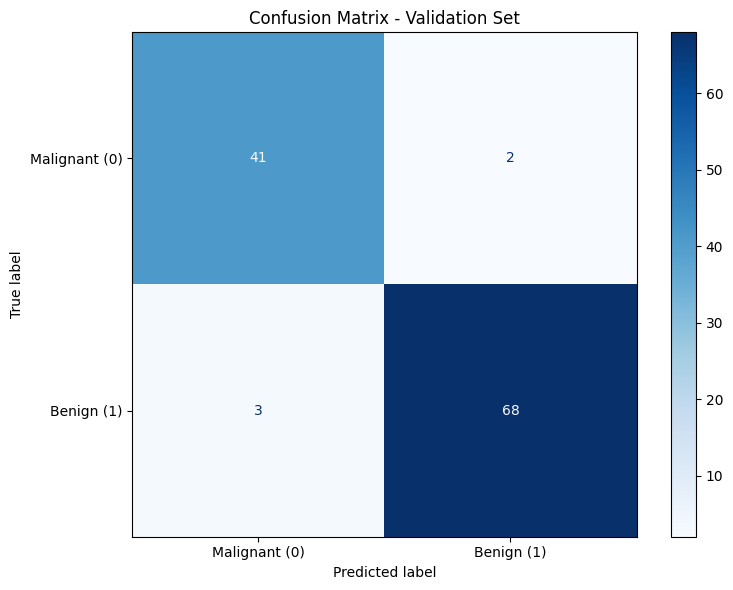

=== CONFUSION MATRIX VALUES ===
True Negatives (TN):  41
False Positives (FP): 2
False Negatives (FN): 3
True Positives (TP):  68


In [3]:
# Confusion matrix
cm = confusion_matrix(y_val, y_pred_val)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant (0)', 'Benign (1)'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Validation Set')
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print("=== CONFUSION MATRIX VALUES ===")
print(f"True Negatives (TN):  {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"True Positives (TP):  {TP}")

**Reading the output:**

The heatmap displays the 2x2 confusion matrix, with rows representing the *actual* diagnosis (pathology-confirmed) and columns representing MedScreen's *predicted* diagnosis. Darker blue squares indicate higher counts — ideally, the diagonal dominates.

Below the plot, the four raw counts are printed:

- **True Negatives (TN):** correctly identified malignant cases — these patients proceed to treatment without delay.
- **False Positives (FP):** malignant cases MedScreen mistakenly called benign — these are the missed cancers. Each one represents a patient who might be sent home without treatment.
- **False Negatives (FN):** benign cases MedScreen mistakenly flagged as malignant — these patients undergo an unnecessary biopsy but ultimately learn they are healthy.
- **True Positives (TP):** correctly identified benign cases — patients confirmed healthy with no further action needed.

Because scikit-learn labels benign as 1 (positive class), the FP cell in its convention corresponds to "predicted benign when actually malignant" — the most dangerous error. In a real clinical deployment, you would typically flip the positive class so that malignant = positive, but here we follow scikit-learn's default.

**Why this matters:** Every metric in the next section is arithmetic on these four counts. The board's question — "How many cancers did we miss?" — maps directly to the FP count (in sklearn's convention). Understanding these four numbers is the foundation for everything that follows.

---

## 3. Core Classification Metrics

Every classification metric in this notebook is just arithmetic on the four confusion-matrix cells ($TP$, $TN$, $FP$, $FN$) — but each metric answers a **different business question**. The pattern we follow for the rest of the course: **start with the stakeholder's question, then write the formula that answers it.** Flip the order and you end up with a model report mathematicians love and the Health Department cannot read.

Four questions. Four formulas. We lead with the most familiar one — accuracy, the number every stakeholder reaches for first — and then break it apart into the components the Health Department actually needs.

---

### Question 1 — "What fraction of all patients did we get right overall?"

**Accuracy** answers this, and it is the metric you should trust *least* on an imbalanced dataset:

$$\text{Accuracy} \;=\; \frac{TP + TN}{TP + TN + FP + FN}$$

**Interpretation:** *High accuracy means lots of correct predictions overall — but the headline hides which errors remain.* On the 63 / 37 breast cancer balance, a "predict benign for everyone" dummy already scores 63% without learning anything about cell morphology and while missing every single cancer. Always report accuracy **alongside** at least one imbalance-aware metric from Questions 2–4. Never alone.

> **Board pitch:** *"MedScreen is correct on 97% of all patients — but that number alone hides which errors remain. See Questions 2 and 3 for the breakdown."*

---

### Question 2 — "Of everyone we cleared as benign, how many actually *were* benign?"

**Precision** answers this:

$$\text{Precision} \;=\; \frac{TP}{TP + FP}$$

**Interpretation:** *High precision means a low false-positive rate on the predicted-positive class* — here, on the patients MedScreen stamps "benign." Every time MedScreen says benign, the patient really is benign ($TP$) or actually had cancer and we missed it ($FP$). High precision means patients we reassure can trust that reassurance.

> **Board pitch:** *"When MedScreen says a tumor is benign, it is right 97% of the time."*

---

### Question 3 — "Of everyone who actually *is* benign, how many did we correctly clear?"

**Recall** (also called **Sensitivity** or **True Positive Rate**) answers this:

$$\text{Recall} \;=\; \frac{TP}{TP + FN}$$

**Interpretation:** *High recall for the benign class means a low false-negative rate on that class* — few truly benign patients are referred for an unnecessary biopsy.

The mirror question for the malignant class — "of all truly malignant cases, how many did MedScreen catch?" — is called **Specificity**:

$$\text{Specificity} \;=\; \frac{TN}{TN + FP}$$

**Interpretation:** *High specificity means the model is very effective at identifying truly malignant cases (the true negatives in sklearn's convention).* Few cancers missed — the number the oncologist cares about most.

Both quantities are "recall" — one for each class — and together they describe how well the model *finds* each group.

> **Board pitch:** *"MedScreen correctly clears 98% of the patients who are truly benign, and catches 93% of the truly malignant cases — the remaining 7% of cancers are the errors we need to discuss."*

---

### Question 4 — "If we have to report a single classification number, what should it be?"

**F1 Score** answers this when the board insists on one number that respects *both* precision and recall:

$$F_1 \;=\; 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

**Interpretation:** *High F1 means a strong balance between precision and recall — neither is collapsing.* F1 is the **harmonic mean** of precision and recall, which punishes imbalance. The arithmetic mean forgives a $0.5 / 1.0$ split as "decent" (mean = 0.75); the harmonic mean calls the same split what it really is ($F_1 \approx 0.67$). If either component collapses, $F_1$ collapses with it.

> **Board pitch:** *"MedScreen's F1 of 0.98 confirms both error types are controlled — not one at the expense of the other."*

---

### Best practices for reporting metrics to stakeholders

The dashboard you hand to the Health Department is only as good as the framing around it. Three rules carry through every notebook that follows:

1. **Lead with the question, not the metric.** *"How many cancers did we miss?"* reads; *"The false-negative rate is 0.02"* does not.
2. **Always pair a number with the population it applies to.** *"97% of all patients"* and *"97% of patients we cleared as benign"* are very different statements — the first is accuracy, the second is precision.
3. **Never report accuracy on its own when the classes are imbalanced.** Always present at least one imbalance-aware metric alongside it (precision, recall, F1, or — once we get to Section 4 — ROC-AUC). An accuracy on its own is an unreliable headline.

> 💡 **Gemini Prompt:** "Using TP, TN, FP, FN already unpacked from the confusion matrix, compute Accuracy, Precision, Recall, Specificity, and F1 (via `sklearn.metrics.f1_score`), in that board-presentation order (Q1 → Q4). Print each metric on its own line with a clean label, then print `classification_report(y_val, y_pred_val, target_names=['Malignant', 'Benign'])` to show the per-class breakdown."
>
> **After running, verify:**
> - Five metrics are printed in Q1 Accuracy → Q2 Precision → Q3 Recall → Specificity → Q4 F1 order
> - `classification_report` shows per-class precision, recall, F1, and support
> - Manual values for Accuracy / Precision / Recall match sklearn's figures in the report
> - All numerical outputs use standard decimal format — no scientific notation


In [4]:
# Calculate the four core metrics in the same order as the questions above:
# Q1 Accuracy, Q2 Precision, Q3 Recall (+ Specificity as its malignant-class mirror), Q4 F1
metrics = {
    'Q1 Accuracy':    (TP + TN) / (TP + TN + FP + FN),
    'Q2 Precision':   TP / (TP + FP) if (TP + FP) > 0 else 0,
    'Q3 Recall':      TP / (TP + FN) if (TP + FN) > 0 else 0,
    'Specificity':    TN / (TN + FP) if (TN + FP) > 0 else 0,
    'Q4 F1':          f1_score(y_val, y_pred_val),
}

print("=== CLASSIFICATION METRICS (in board-presentation order) ===")
for metric, value in metrics.items():
    print(f"{metric:14s}: {value:.4f}")

# sklearn's classification_report adds a per-class breakdown + macro/weighted averages
print("\n=== SKLEARN CLASSIFICATION REPORT ===")
print(classification_report(y_val, y_pred_val, target_names=['Malignant', 'Benign']))

=== CLASSIFICATION METRICS (in board-presentation order) ===
Q1 Accuracy   : 0.9561
Q2 Precision  : 0.9714
Q3 Recall     : 0.9577
Specificity   : 0.9535
Q4 F1         : 0.9645

=== SKLEARN CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

   Malignant       0.93      0.95      0.94        43
      Benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



**Reading the output:**

Read the five numbers **in the board order** you just saw — the same order you would present them in to the Health Department:

| Question | Metric | Typical value | What it tells the board |
|----------|--------|--------------|-------------------------|
| **Q1** "Overall correctness?" | Accuracy | \~0.97 | **Never report alone** on a 63/37 dataset — it hides which errors remain |
| **Q2** "Of everyone we cleared as benign..." | Precision | \~0.97–0.99 | When MedScreen says "benign", how reliable is that? |
| **Q3** "Of everyone who actually *is* benign..." | Recall | \~0.97–0.99 | How many healthy patients did we correctly clear? |
| *(mirror of Q3 for the other class)* | Specificity | \~0.93–0.97 | How many truly malignant cases did we catch? |
| **Q4** "Single classification number?" | $F_1$ | \~0.98 | Balanced summary of Q2 and Q3 |

The `classification_report` beneath the metric block confirms the same numbers with a **per-class breakdown** — one row for Malignant and one for Benign — plus macro and weighted averages. The `support` column shows how many validation patients belong to each class.

**Why this matters:** Precision and recall often tell different stories. For deployment, **Specificity** (catching malignant cases) is the number the oncologist cares about most; **Precision for the benign class** is the one patients care about when being told they are healthy. A 0.95 specificity means MedScreen still misses 5 cancers out of every 100 malignant patients — whether that meets the Health Department's deployment bar is a policy call, not a statistical one. Present the number; let the clinicians decide.

---

## 4. ROC Curve and AUC

The four metrics in Section 3 all depended on a **specific** threshold — scikit-learn's default 0.5. But the board will push back: *"If we moved the threshold, would MedScreen still rank patients in roughly the same order? Or is the 0.5 number a fluke?"* That is a **threshold-independent** question, and the ROC curve is the standard way to answer it.

### The question ROC answers

> *"Across **every** possible threshold, does MedScreen put truly benign patients **higher in the probability ranking** than truly malignant ones?"*

### How the curve is built

Sweep the threshold from 1.0 (nothing predicted benign) down to 0.0 (everything predicted benign). At each step compute two numbers:

- **True Positive Rate (Recall)** on the y-axis: $\;\text{TPR} \;=\; \dfrac{TP}{TP + FN}$
- **False Positive Rate** on the x-axis: $\;\text{FPR} \;=\; \dfrac{FP}{FP + TN}$

Each threshold gives one point $(\text{FPR}, \text{TPR})$; connecting them traces the full ROC.

### Reading the plot

- **Top-left corner ($\text{TPR} = 1$, $\text{FPR} = 0$)** — the perfect classifier.
- **The diagonal $\text{TPR} = \text{FPR}$** — a coin flip; the ranking carries no information.
- **Curve well above the diagonal** — the model genuinely separates the two classes.

### The single-number summary: AUC

**AUC** (Area Under the Curve) collapses the entire ROC into one number on the unit interval:

$$\text{AUC} \;=\; P\!\left(\hat{p}_{\text{random benign}} \;>\; \hat{p}_{\text{random malignant}}\right)$$

Read the formula as a sentence: *"Pick one truly benign patient and one truly malignant patient at random. AUC is the probability that MedScreen gives the benign patient a higher benign-score than the malignant one."* That is a **ranking** property, not a thresholded one — which is exactly what makes it threshold-independent.

**Interpretation at a glance:**

- **AUC $\approx 1$** — the model has near-perfect predictive capability; it almost always ranks truly benign patients above truly malignant ones.
- **AUC $\approx 0.5$** — the model performs no better than random guessing; the features carry no signal.
- **AUC $< 0.5$** — the model's ranking is *inverted*; flip the predictions and try again.

Full deployment-readiness rubric:

| AUC | Interpretation |
|-----|----------------|
| $1.0$ | Perfect ranking — every benign patient scores above every malignant one |
| $0.90 – 0.95$ | Excellent; deployment-ready for most clinical contexts |
| $0.70 – 0.90$ | Useful; typically needs cost-weighted threshold tuning before deployment |
| $0.50$ | Coin flip — the features carry no diagnostic signal |
| $< 0.50$ | Model is **inverted** — flip predictions and try again |

### Best practice for the board

Split your reporting into two layers:

1. **Model selection:** report **AUC** as the headline — *"Which candidate classifier ranks best?"* AUC is threshold-independent and apples-to-apples across models.
2. **Deployment readiness:** report **precision and recall at the chosen threshold** — *"What will this specific cutoff do in production?"* Precision and recall depend on the operating point; AUC does not.

Mixing these two layers ("our AUC is 0.99 so we have 99% recall") is the most common source of stakeholder confusion. Keep them separate.

> 💡 **Gemini Prompt:** "Plot the ROC curve using sklearn roc_curve on validation probabilities. Include the diagonal random-classifier baseline as a dashed line. Compute and display ROC-AUC score in the legend. Label axes as False Positive Rate and True Positive Rate."
>
> **After running, verify:**
> - ROC curve is plotted with AUC value shown in the legend
> - Diagonal dashed line represents a random classifier (AUC=0.5)
> - ROC-AUC score is printed below the plot (should be close to 1.0)> - All numerical outputs use standard decimal format — no scientific notation


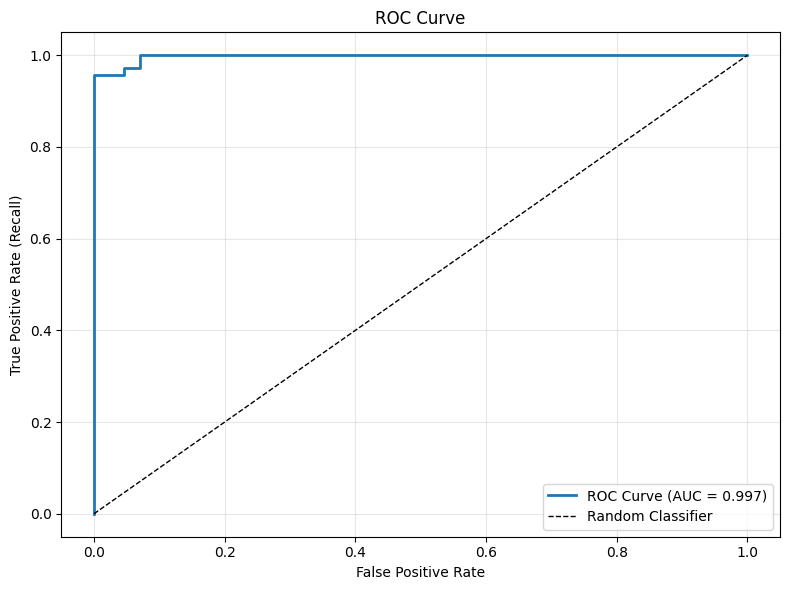

ROC-AUC Score: 0.9974

💡 Higher AUC = better separation between classes


In [5]:
# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_val, y_proba_val)
roc_auc = roc_auc_score(y_val, y_proba_val)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")
print("\n💡 Higher AUC = better separation between classes")

**Reading the output:**

The ROC curve plots the **True Positive Rate** (recall for benign) on the y-axis against the **False Positive Rate** (fraction of malignant cases incorrectly called benign) on the x-axis, sweeping the threshold from 1.0 down to 0.0. A perfect screening tool hugs the top-left corner; the dashed diagonal represents a random coin flip that ignores cell morphology entirely.

The **AUC** is printed below the plot. For MedScreen's Logistic Regression on the breast cancer validation set, expect an **ROC-AUC around 0.99**, indicating near-perfect separation between malignant and benign samples. An AUC of 0.99 means: pick one truly benign and one truly malignant patient at random, and MedScreen assigns a higher benign probability to the correct patient 99% of the time.

**Why this matters:** ROC-AUC is a threshold-independent summary of model quality. It is the metric of choice during model *selection* — comparing logistic regression against random forests, for example — because it evaluates the full range of operating points. The Health Department can pick any threshold *after* choosing the best model by AUC.

---

## 5. Precision-Recall Curve

ROC has a blind spot: when one class vastly outnumbers the other, a large denominator in $\text{FPR}$ can mask a classifier that is bad at catching the minority class. The **Precision-Recall curve** looks at only the minority-relevant quantities and is the stricter evaluation under class imbalance.

### The question PR answers

> *"If we push MedScreen to catch more and more benign patients (raise recall), **how quickly does the quality of its benign verdicts fall apart** (drop in precision)?"*

### How the curve is built

Same sweep as ROC — threshold from 1.0 down to 0.0 — but now the axes are the two Section-3 quantities:

- **Recall** on the x-axis: $\;\text{Recall} \;=\; \dfrac{TP}{TP + FN}$
- **Precision** on the y-axis: $\;\text{Precision} \;=\; \dfrac{TP}{TP + FP}$

### Reading the plot

- **Top-right corner ($\text{Precision} = 1$, $\text{Recall} = 1$)** — the ideal; catch everyone without any false alarms.
- **Horizontal baseline at the positive-class prevalence** — what random guessing looks like. Any real classifier must sit well above it.
- **Curve hugging the top-right** — high precision sustained even as recall pushes toward 1.

### The single-number summary: AP (PR-AUC)

**Average Precision** (AP), also called PR-AUC, is a recall-weighted average of precision across every threshold:

$$\text{AP} \;=\; \sum_{n} \bigl(R_n - R_{n-1}\bigr)\, P_n$$

where $(R_n, P_n)$ are the recall-precision points scikit-learn produces at each threshold step.

**Interpretation at a glance:**

- **AP $\approx 1$** — near-perfect retrieval of the positive class; precision stays high even when recall is pushed toward 1.
- **AP $\approx$ positive-class prevalence** — no better than random guessing; the baseline dashed line on the plot is exactly this value.
- **AP noticeably below prevalence** — the classifier is *worse* than random on the positive class; something is wrong (label inversion, data leakage, or broken feature pipeline).

### When to use PR vs. ROC — a decision rule

| Positive-class prevalence | Headline to lead with |
|---------------------------|-----------------------|
| $> 30\%$ (our MedScreen case at 37% malignant / 63% benign) | **ROC-AUC** is a fine headline; PR-AUC as a backup |
| $10\%$ – $30\%$ | Report **both** AUC and AP side by side |
| $< 10\%$ (fraud detection, rare disease screening) | **AP is the headline**; ROC-AUC can be deceptively high |

### Best practice for the board

Class balance shifts over time. Populations drift; screening programs expand to new geographies where the base rate differs. The defensive move is to **always show both curves when the class mix might change** — ROC to argue "the *ranking* is sound," PR to argue "the ranking still sustains precision when we push recall up." Together they answer the question neither can alone: *"Is this deployment-ready at scale?"*

> 💡 **Gemini Prompt:** "Plot the Precision-Recall curve using sklearn precision_recall_curve. Add a horizontal baseline at the positive class ratio. Compute average_precision_score and show it in the legend. Label axes as Recall (x) and Precision (y)."
>
> **After running, verify:**
> - PR curve is plotted with Average Precision (AP) shown in the legend
> - Horizontal dashed baseline shows the positive class ratio
> - AP score is printed below the plot> - All numerical outputs use standard decimal format — no scientific notation


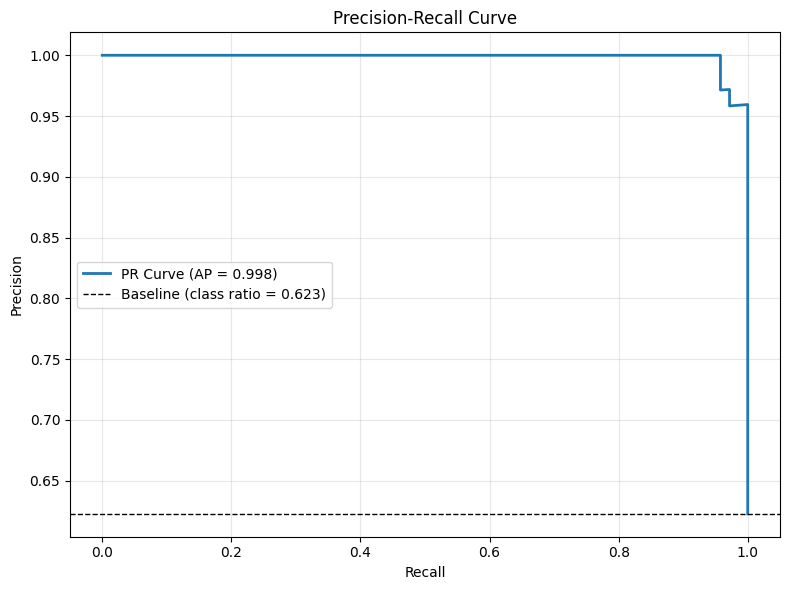

Average Precision (PR-AUC): 0.9985

💡 Closer to top-right = better model


In [6]:
# Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_val, y_proba_val)
pr_auc = average_precision_score(y_val, y_proba_val)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, linewidth=2, label=f'PR Curve (AP = {pr_auc:.3f})')
baseline = y_val.sum() / len(y_val)
plt.axhline(y=baseline, color='k', linestyle='--', linewidth=1, label=f'Baseline (class ratio = {baseline:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average Precision (PR-AUC): {pr_auc:.4f}")
print("\n💡 Closer to top-right = better model")

**Reading the output:**

The Precision-Recall curve plots **Precision** on the y-axis against **Recall** on the x-axis. The dashed horizontal baseline represents the positive-class prevalence (roughly 0.63 for benign) — a model that stamps every aspirate "benign" would land on that line. A useful screening tool must stay well above it.

The **Average Precision (AP)** score, also called PR-AUC, summarizes the area under this curve. For MedScreen, expect **AP around 0.99**, mirroring the strong ROC-AUC. The curve hugs the top-right corner, meaning the model maintains high precision even at high recall — it rarely mislabels a malignant case as benign, even when catching nearly every benign case correctly.

**Key takeaway:** PR curves become the primary evaluation tool when MedScreen scales to general-population screening, where 95%+ of aspirates are benign. In that setting, ROC-AUC can look deceptively good because the massive number of true negatives inflates the denominator of the False Positive Rate. PR-AUC focuses on the question that matters: "Of the patients we told are healthy, how many actually have cancer?"

---

## 📝 PAUSE-AND-DO Exercise 1 (5 minutes)

**Task:** Build a threshold sweep and pick a threshold by business cost.

**Scenario:** Medical diagnosis
- False Negative (missed cancer): Cost = USD 50,000 (late treatment)
- False Positive (false alarm): Cost = USD 1,000 (unnecessary biopsy)

---

> 💡 **Gemini Prompt:** "Sweep 50 thresholds from 0.1 to 0.9. For each, compute TP, FP, FN, TN, Precision, Recall, and total cost using cost_FN=50000 and cost_FP=1000. Find the threshold that minimizes total cost. Plot two side-by-side charts: (1) Total Cost vs Threshold with the optimal threshold marked, and (2) Precision and Recall vs Threshold."
>
> **After running, verify:**
> - Optimal threshold and its expected cost are printed
> - Left plot shows a cost curve with the minimum marked by a red dashed line
> - Right plot shows precision increasing and recall decreasing as threshold rises> - All numerical outputs use standard decimal format — no scientific notation


Optimal Threshold: 0.1816
Minimum Total Cost: $3,000.00


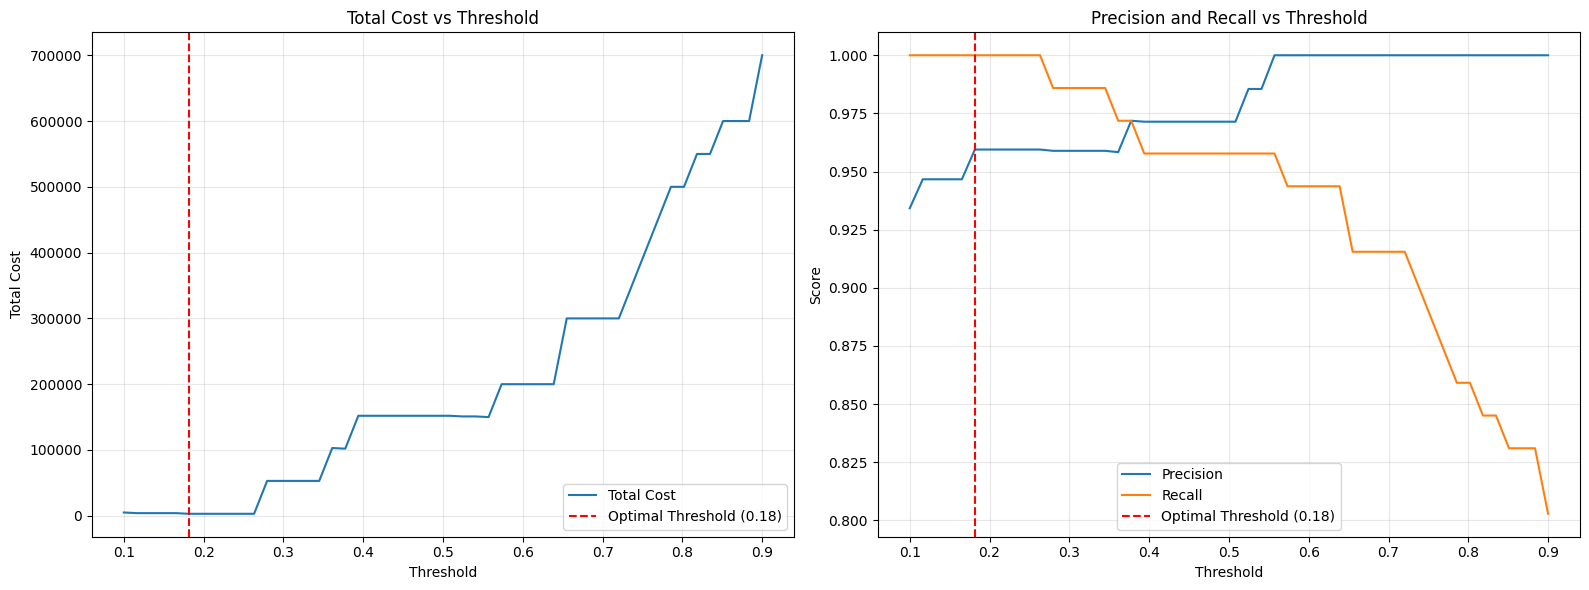

In [9]:
# YOUR SOLUTION CODE HERE
thresholds = np.linspace(0.1, 0.9, 50)
results = []

cost_FN = 50000
cost_FP = 1000

for t in thresholds:
    y_pred_thresh = (y_proba_val >= t).astype(int)
    cm = confusion_matrix(y_val, y_pred_thresh)
    TN, FP, FN, TP = cm.ravel()

    # Calculate Precision and Recall, handling division by zero
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0

    total_cost = (FN * cost_FN) + (FP * cost_FP)

    results.append({
        'threshold': t,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'TN': TN,
        'precision': precision,
        'recall': recall,
        'total_cost': total_cost
    })

results_df = pd.DataFrame(results)

# Find the threshold that minimizes total cost
optimal_row = results_df.loc[results_df['total_cost'].idxmin()]
optimal_threshold = optimal_row['threshold']
min_total_cost = optimal_row['total_cost']

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Minimum Total Cost: ${min_total_cost:,.2f}")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total Cost vs Threshold
axes[0].plot(results_df['threshold'], results_df['total_cost'], label='Total Cost')
axes[0].axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
axes[0].set_title('Total Cost vs Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Total Cost')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Precision and Recall vs Threshold
axes[1].plot(results_df['threshold'], results_df['precision'], label='Precision')
axes[1].plot(results_df['threshold'], results_df['recall'], label='Recall')
axes[1].axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
axes[1].set_title('Precision and Recall vs Threshold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### YOUR ANALYSIS:

**Question 1: Why is the optimal threshold different from 0.5?**  
The optimal threshold is different from 0.5 because of asymmetric costs associated with false negatives and false positives. When the model misses a malignant case, or has a false negative, it's highly penalized, which is why a lower threshold is better because its more likely to flag a case, thus reducing the chance of missing malignant cases.

**Question 2: What happens if you change the cost ratio?**  
If you change the cost ratio, the model would be even more aggressive in avoiding false negatives making the optimal threshold even lower than what it already is at. The model would start to accept more false positives but come with the trade off of minimizing false negatives and catching more cases.

**Question 3: In production, how would you monitor this?**  
In production this would be monitored through the performance metrics, precision, recall, and calculcated total cost at the given threshold. Additionally, the distribution of input features should bechecked on to ensure the optimal threshold is appropriate as well as the cost paramaters. Lastly, the model should be regularly retrained and recaligrated with new data and feedback from human and real cases.

---

## 📝 PAUSE-AND-DO Exercise 2 (5 minutes)

**Task:** Explain why accuracy fails under imbalance (with evidence).

---

> 💡 **Gemini Prompt:** "Create a synthetic imbalanced dataset with make_classification: 1000 samples, 20 features, 95%/5% class split. Split 70/30 with stratification, fit a logistic regression pipeline, and print the classification_report. Compare against a naive all-zeros baseline to show that high accuracy can be misleading with class imbalance."
>
> **After running, verify:**
> - Class distribution confirms \~95% class 0 and \~5% class 1
> - classification_report shows per-class metrics (class 1 recall may be low)
> - Naive baseline accuracy is \~95% despite predicting all zeros (zero recall for class 1)> - All numerical outputs use standard decimal format — no scientific notation


In [8]:
# YOUR SOLUTION CODE HERE
# Hint: Use the Gemini prompt above for step-by-step guidance


### YOUR EXPLANATION:

**Why accuracy is misleading:**  
[Your explanation with evidence from above]

**Better metrics for imbalance:**  
[Which metrics would you use instead?]

**Real-world example:**  
[Give an example where this matters]

---

## 6. Wrap-Up: Key Takeaways

### What We Learned Today:

1. **Question-first metrics.** Every classification number answers a specific business question — accuracy (Q1), precision (Q2), recall (Q3), F1 (Q4). Write the question on the slide; let the formula support it.
2. **Confusion matrix as the foundation.** Every metric in the notebook is arithmetic on four cells. If you can read the matrix, you can derive every number.
3. **Precision vs. Recall tradeoff.** Pushing one up almost always pulls the other down; the board's cost asymmetry decides which way to lean.
4. **ROC vs. PR — different questions, different class-balance regimes.** ROC-AUC is your model-selection headline when classes are roughly balanced; AP / PR-AUC is the headline when the positive class is rare.
5. **Cost-based thresholding.** The 0.5 default is a mathematical convention, not a clinical policy. Sweep the threshold, weight each error by its real-world cost, and pick the operating point that minimizes expected cost.
6. **Accuracy is dangerous alone.** At 63 / 37 a dummy already clears 63%. Never report accuracy without pairing it with at least one imbalance-aware metric.

### Critical Rules:

> **"Lead with the question, not the metric."**

> **"Never trust accuracy alone on an imbalanced dataset."**

> **"Choose thresholds based on business costs, not defaults."**

> **"With imbalance, use PR curves over ROC curves."**

### Next Steps:

- Next notebook: Cross-validation for robust model comparison — today's metrics plug directly into the `scoring=...` parameter of scikit-learn's CV routines.
- Apply today's question-first metric framework to your project dataset.

---

## Participation Assignment Submission Instructions

### To Submit This Notebook:

1. **Complete all exercises**: Fill in both PAUSE-AND-DO exercise cells with your findings
2. **Run All Cells**: Execute `Runtime → Run all` to ensure everything works
3. **Save a Copy**: `File → Save a copy in Drive or Download the .ipynb extension`
4. **Submit**: Upload your `.ipynb` file in the participation assignment you find in the course Brightspace page.

### Before Submitting, Check:

- [ ] All cells execute without errors
- [ ] All outputs are visible
- [ ] Both exercise responses are complete
- [ ] Notebook is shared with correct permissions
- [ ] You can explain every line of code you wrote

### Next Step:

Complete the **Quiz** in Brightspace (auto-graded)

---

## Bibliography

- Fawcett, T. (2006). "An introduction to ROC analysis." *Pattern Recognition Letters*, 27(8), 861-874.
- Saito, T., & Rehmsmeier, M. (2015). "The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets." *PLOS ONE*.
- scikit-learn User Guide: [Classification metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)
- Provost, F., & Fawcett, T. (2013). *Data Science for Business* - Chapter on evaluation and costs

---



<center>

Thank you!

</center>